# 03 - Support Vector Machine: RBF, sigmoid and polynomial kernels (Person 2)
**Task:** predict whether a mortgage is fully prepaid within 24 months (`1`) or not (`0`).

This notebook trains the SVM with three kernels, all using the "kernel trick": **RBF**, **sigmoid** and **polynomial**. It uses the **saved** files from `01_data_preprocessing.ipynb` (`data/processed/`). It does not preprocess again, re-split, or touch the raw data, so all three kernels (and the other models) are scored on the same 9,823-loan test set.

The RBF SVM keeps the tag `svm` (same settings and results as before), so `06_model_comparison.ipynb` is unchanged. The two new kernels are saved as `svm_sigmoid` and `svm_polynomial`.

In [1]:
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

In [2]:
# ---- Paths: works whether Jupyter is started in the project root or in notebooks/ ----
import os
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
METRICS_DIR = os.path.join(PROJECT_ROOT, "results", "metrics")
PRED_DIR = os.path.join(PROJECT_ROOT, "results", "predictions")
CM_DIR = os.path.join(PROJECT_ROOT, "results", "confusion_matrices")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "results", "plots")
for d in (METRICS_DIR, PRED_DIR, CM_DIR, PLOTS_DIR):
    os.makedirs(d, exist_ok=True)
RANDOM_STATE = 42

## 1. Load and verify the data

In [3]:
# ---- Load the SAVED processed files (no re-preprocessing, no new split) ----
X_train = pd.read_csv(os.path.join(PROCESSED, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED, "y_test.csv")).squeeze("columns")

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Same feature names and order in train and test:", list(X_train.columns) == list(X_test.columns))
print("Rows match targets:", len(X_train) == len(y_train), len(X_test) == len(y_test))
print("Missing values in X (train/test):", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))
print("Target values:", sorted(y_train.unique()), "(1 = prepaid within 24 months = positive class)")
print("Class balance train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance test :", y_test.value_counts(normalize=True).round(3).to_dict())

# These numbers come from the assignment text; the notebook only warns if the files differ.
expected = {"train": 39288, "test": 9823, "features": 20}
if (len(X_train), len(X_test), X_train.shape[1]) != (expected["train"], expected["test"], expected["features"]):
    print("WARNING: shapes differ from the 39,288 / 9,823 / 20 described in the assignment. Check the files.")
assert list(X_train.columns) == list(X_test.columns), "Feature columns differ between train and test"
assert len(X_train) == len(y_train) and len(X_test) == len(y_test), "Feature/target length mismatch"

X_train: (39288, 20) | X_test: (9823, 20)
y_train: (39288,) | y_test: (9823,)
Same feature names and order in train and test: True
Rows match targets: True True
Missing values in X (train/test): 0 0
Target values: [np.int64(0), np.int64(1)] (1 = prepaid within 24 months = positive class)
Class balance train: {1: 0.524, 0: 0.476}
Class balance test : {1: 0.524, 0: 0.476}


## 2. The three kernels and their settings
Settings are **fixed in advance** (no grid search) and the test set is never used to choose them. `class_weight` stays at the default so the SVMs are comparable with the other models.

| Kernel | Settings | Why |
|---|---|---|
| RBF | `C=1.0`, `gamma="scale"` | The baseline from the assignment (unchanged). |
| Sigmoid | `C=1.0`, `gamma="scale"`, `coef0=0.0` | scikit-learn defaults, so no tuning advantage over RBF. |
| Polynomial | `degree=3`, `C=1.0`, `gamma="scale"`, `coef0=1.0` | The usual cubic kernel; `coef0=1` keeps the lower-order terms (the default `0` would use only pure cubic terms). |

`gamma="scale"` is `1 / (n_features * X.var())` for all three. `cache_size=1000` (MB) only speeds up training and does not change the result. Training can take a few minutes per kernel.

In [4]:
KERNELS = [  # tag used in results/ file names, label, SVC settings
    ("svm",            "SVM (RBF, C=1.0, gamma=scale)",
     dict(kernel="rbf", C=1.0, gamma="scale")),
    ("svm_sigmoid",    "SVM (Sigmoid, C=1.0, gamma=scale, coef0=0)",
     dict(kernel="sigmoid", C=1.0, gamma="scale", coef0=0.0)),
    ("svm_polynomial", "SVM (Polynomial, degree=3, C=1.0, gamma=scale, coef0=1)",
     dict(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0)),
]
SHORT = {"svm": "RBF", "svm_sigmoid": "Sigmoid", "svm_polynomial": "Polynomial"}

models, fit_seconds = {}, {}
for tag, label, params in KERNELS:
    model = SVC(**params, cache_size=1000, random_state=RANDOM_STATE)   # no probability=True: not needed
    start = time.time()
    model.fit(X_train, y_train)
    fit_seconds[tag] = time.time() - start
    models[tag] = model
    print(f"{SHORT[tag]:<11} | training time {fit_seconds[tag]:6.1f} s | support vectors per class "
          f"{dict(zip(model.classes_.tolist(), model.n_support_.tolist()))} "
          f"({model.n_support_.sum() / len(X_train):.1%} of training points) | gamma used {model._gamma:.4f}")

RBF         | training time  398.5 s | support vectors per class {0: 14952, 1: 14924} (76.0% of training points) | gamma used 0.0831
Sigmoid     | training time  424.5 s | support vectors per class {0: 9257, 1: 9254} (47.1% of training points) | gamma used 0.0831
Polynomial  | training time  429.2 s | support vectors per class {0: 14850, 1: 14839} (75.6% of training points) | gamma used 0.0831


## 3. Predictions and decision scores

In [5]:
y_pred, scores = {}, {}
for tag, _, _ in KERNELS:
    y_pred[tag] = models[tag].predict(X_test)
    scores[tag] = models[tag].decision_function(X_test)    # signed distance to the boundary; larger = more 'prepaid'
    print(f"{SHORT[tag]:<11} classes {models[tag].classes_} -> positive score means class {models[tag].classes_[1]} | "
          f"predicted class counts {pd.Series(y_pred[tag]).value_counts().to_dict()}")

RBF         classes [0 1] -> positive score means class 1 | predicted class counts {1: 5427, 0: 4396}
Sigmoid     classes [0 1] -> positive score means class 1 | predicted class counts {1: 5207, 0: 4616}
Polynomial  classes [0 1] -> positive score means class 1 | predicted class counts {1: 5767, 0: 4056}


## 4. Evaluation on the existing test set (positive class = 1)

In [6]:
def evaluate(model_name, y_true, y_pred, scores):
    """Same metric definitions for every model. Positive class = 1 (prepayment)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),   # continuous scores, NOT hard 0/1 predictions
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "n_test": int(len(y_true)),
    }


def plot_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No prepayment (0)", "Prepayment (1)"])
    ax.set_yticklabels(["No prepayment (0)", "Prepayment (1)"])
    ax.set_xlabel("Predicted class"); ax.set_ylabel("Actual class"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)

In [7]:
all_metrics = {}
for tag, label, params in KERNELS:
    m = evaluate(label, y_test, y_pred[tag], scores[tag])
    m.update({"kernel": params["kernel"], "hyperparameters": {**params, "cache_size": 1000},
              "fit_seconds": round(fit_seconds[tag], 1),
              "n_support_vectors": int(models[tag].n_support_.sum()),
              "n_train": int(len(X_train))})
    all_metrics[tag] = m

baseline = max(y_test.mean(), 1 - y_test.mean())
summary = pd.DataFrame([{"kernel": SHORT[t], **{k: all_metrics[t][k] for k in
                         ["accuracy", "precision", "recall", "f1", "roc_auc", "tn", "fp", "fn", "tp"]},
                         "fit_seconds": all_metrics[t]["fit_seconds"],
                         "support_vector_share": all_metrics[t]["n_support_vectors"] / len(X_train)} for t, _, _ in KERNELS]
                       ).set_index("kernel")
print(summary.round(4).to_string())
print()
print("Majority-class baseline accuracy (always predict the larger class):", round(baseline, 4))
print("\nPredicted-positive share (actual share of class 1 in the test set is "
      f"{y_test.mean():.3f}): " + ", ".join(f"{SHORT[t]} {y_pred[t].mean():.3f}" for t, _, _ in KERNELS))

            accuracy  precision  recall      f1  roc_auc    tn    fp    fn    tp  fit_seconds  support_vector_share
kernel                                                                                                             
RBF           0.6534     0.6608  0.6963  0.6781   0.7065  2832  1841  1564  3586        398.5                0.7604
Sigmoid       0.5448     0.5652  0.5715  0.5683   0.5293  2409  2264  2207  2943        424.5                0.4712
Polynomial    0.6540     0.6518  0.7299  0.6887   0.7068  2665  2008  1391  3759        429.2                0.7557

Majority-class baseline accuracy (always predict the larger class): 0.5243

Predicted-positive share (actual share of class 1 in the test set is 0.524): RBF 0.552, Sigmoid 0.530, Polynomial 0.587


## 5. Save results in the shared `results/` layout
For each kernel: confusion matrix CSV, metrics JSON, test predictions CSV, and the confusion-matrix and ROC plots, with the same file names as the other models (`svm`, `svm_sigmoid`, `svm_polynomial`). A kernel comparison table is saved too.

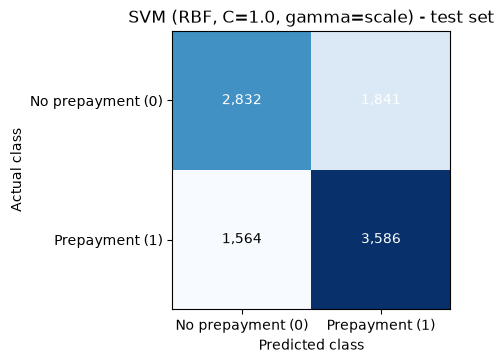

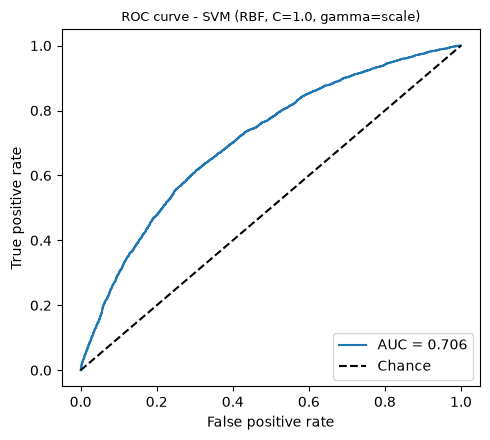

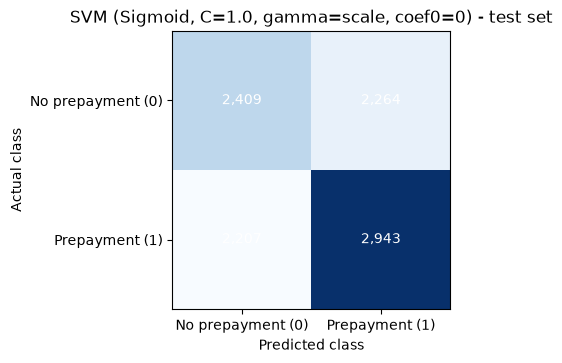

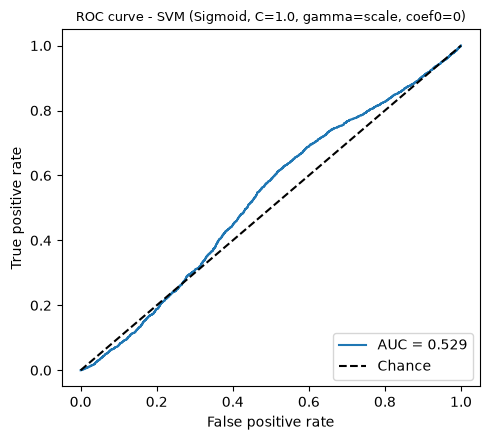

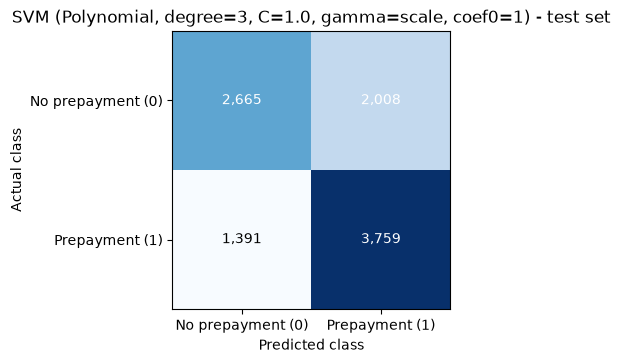

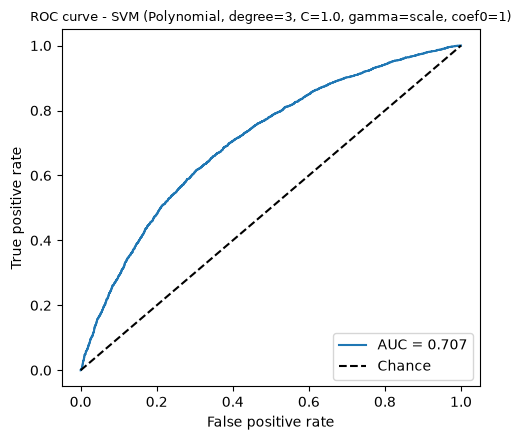

saved   p:\ML-Mini-Project\results\confusion_matrices/svm_confusion_matrix.csv
saved   p:\ML-Mini-Project\results\metrics/svm_metrics.json
saved   p:\ML-Mini-Project\results\metrics/svm_test_predictions.csv
saved   p:\ML-Mini-Project\results\plots/svm_confusion_matrix.png
saved   p:\ML-Mini-Project\results\plots/svm_roc_curve.png
saved   p:\ML-Mini-Project\results\confusion_matrices/svm_sigmoid_confusion_matrix.csv
saved   p:\ML-Mini-Project\results\metrics/svm_sigmoid_metrics.json
saved   p:\ML-Mini-Project\results\metrics/svm_sigmoid_test_predictions.csv
saved   p:\ML-Mini-Project\results\plots/svm_sigmoid_confusion_matrix.png
saved   p:\ML-Mini-Project\results\plots/svm_sigmoid_roc_curve.png
saved   p:\ML-Mini-Project\results\confusion_matrices/svm_polynomial_confusion_matrix.csv
saved   p:\ML-Mini-Project\results\metrics/svm_polynomial_metrics.json
saved   p:\ML-Mini-Project\results\metrics/svm_polynomial_test_predictions.csv
saved   p:\ML-Mini-Project\results\plots/svm_polynomial_

In [8]:
def save_in_team_format(name, y_true, y_pred_, scores_, metrics):
    """Save one model's results in the shared results/ layout:
    confusion_matrices/<name>_confusion_matrix.csv
    metrics/<name>_metrics.json, metrics/<name>_test_predictions.csv
    plots/<name>_confusion_matrix.png, plots/<name>_roc_curve.png
    """
    cm = confusion_matrix(y_true, y_pred_, labels=[0, 1])      # rows = actual, columns = predicted
    pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]).to_csv(
        os.path.join(CM_DIR, f"{name}_confusion_matrix.csv"))
    with open(os.path.join(METRICS_DIR, f"{name}_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2, default=float)
    pd.DataFrame({"row_index": np.arange(len(y_true)), "y_true": np.asarray(y_true),
                  "y_pred": np.asarray(y_pred_), "decision_score": np.asarray(scores_)}).to_csv(
        os.path.join(METRICS_DIR, f"{name}_test_predictions.csv"), index=False)
    plot_confusion(y_true, y_pred_, f"{metrics['model']} - test set",
                   os.path.join(PLOTS_DIR, f"{name}_confusion_matrix.png"))
    fpr, tpr, _ = roc_curve(y_true, scores_)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", label="Chance")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC curve - {metrics['model']}", fontsize=9); ax.legend(loc="lower right")
    fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, f"{name}_roc_curve.png"), dpi=150)
    plt.show(); plt.close(fig)


for tag, _, _ in KERNELS:
    save_in_team_format(tag, y_test.values, y_pred[tag], scores[tag], all_metrics[tag])

summary.round(4).to_csv(os.path.join(METRICS_DIR, "svm_kernel_comparison.csv"))

expected = []
for tag, _, _ in KERNELS:
    expected += [f"confusion_matrices/{tag}_confusion_matrix.csv", f"metrics/{tag}_metrics.json",
                 f"metrics/{tag}_test_predictions.csv", f"plots/{tag}_confusion_matrix.png", f"plots/{tag}_roc_curve.png"]
expected.append("metrics/svm_kernel_comparison.csv")
for f in expected:
    p = os.path.join(PROJECT_ROOT, "results", f)
    print(("saved   " if os.path.exists(p) else "MISSING ") + p)

## 6. Kernel comparison plots

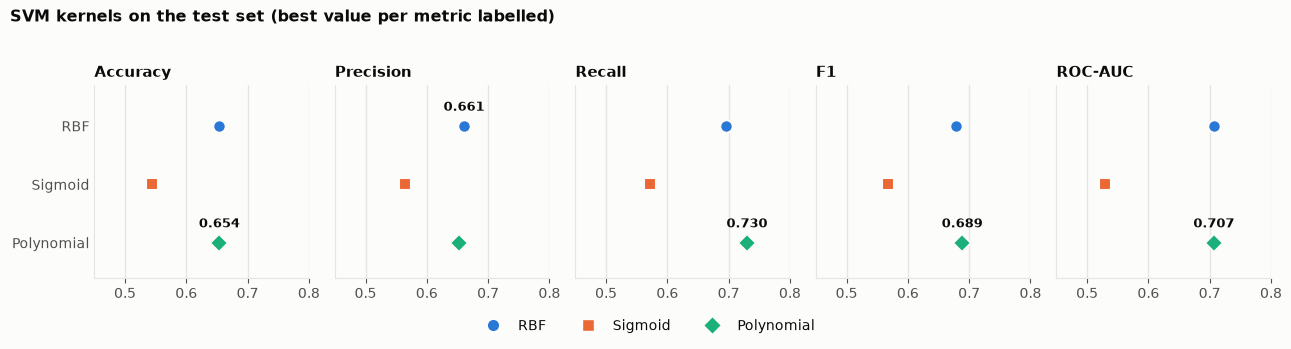

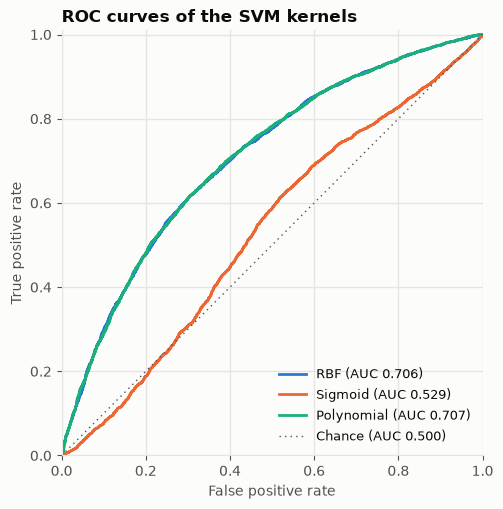

In [9]:
# Chart style: one fixed colour per kernel, text in ink colours, recessive grid
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
KCOLOR = {"svm": "#2a78d6", "svm_sigmoid": "#eb6834", "svm_polynomial": "#1baf7a"}
KMARK = {"svm": "o", "svm_sigmoid": "s", "svm_polynomial": "D"}
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
                     "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
                     "axes.edgecolor": GRID, "axes.titlecolor": INK, "axes.titleweight": "bold",
                     "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
                     "grid.color": GRID, "grid.linewidth": 1})
METRIC_COLS = [("accuracy", "Accuracy"), ("precision", "Precision"), ("recall", "Recall"),
               ("f1", "F1"), ("roc_auc", "ROC-AUC")]
tags = [t for t, _, _ in KERNELS]

# ---- Plot 1: the five metrics for the three kernels ----
fig, axes = plt.subplots(1, 5, figsize=(13, 3.3), sharey=True)
ypos = np.arange(len(tags))[::-1]
vals_all = [all_metrics[t][m] for t in tags for m, _ in METRIC_COLS]
lo, hi = np.floor((min(vals_all) - 0.03) * 20) / 20, np.ceil((max(vals_all) + 0.03) * 20) / 20
for ax, (m, nm) in zip(axes, METRIC_COLS):
    ax.grid(axis="x"); ax.set_axisbelow(True)
    for y, t in zip(ypos, tags):
        ax.plot(all_metrics[t][m], y, marker=KMARK[t], ms=9, color=KCOLOR[t], mec=SURFACE, mew=1.5, ls="none")
    best = max(tags, key=lambda t: all_metrics[t][m])
    ax.annotate(f"{all_metrics[best][m]:.3f}", (all_metrics[best][m], ypos[tags.index(best)]),
                xytext=(0, 11), textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color=INK)
    ax.set_xlim(lo, hi); ax.set_ylim(-0.6, len(tags) - 0.3); ax.set_title(nm, loc="left", fontsize=11)
    ax.tick_params(axis="y", length=0)
axes[0].set_yticks(ypos); axes[0].set_yticklabels([SHORT[t] for t in tags], fontsize=10)
handles = [plt.Line2D([], [], marker=KMARK[t], color=KCOLOR[t], ms=9, lw=0, mec=SURFACE, label=SHORT[t]) for t in tags]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04), fontsize=10)
fig.suptitle("SVM kernels on the test set (best value per metric labelled)", x=0.01, ha="left",
             fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
fig.savefig(os.path.join(PLOTS_DIR, "svm_kernel_comparison_metrics.png"), dpi=200, bbox_inches="tight"); plt.show(); plt.close(fig)

# ---- Plot 2: ROC curves of the three kernels ----
fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.grid(True); ax.set_axisbelow(True)
for t in tags:
    fpr, tpr, _ = roc_curve(y_test, scores[t])
    ax.plot(fpr, tpr, color=KCOLOR[t], lw=2, label=f"{SHORT[t]} (AUC {all_metrics[t]['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], color=INK2, lw=1, ls=(0, (1, 3)), label="Chance (AUC 0.500)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.01); ax.set_aspect("equal")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves of the SVM kernels", loc="left"); ax.legend(loc="lower right", fontsize=9.5)
fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, "svm_kernel_comparison_roc_curves.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)

### 7. Interpretation (numbers from the tables above)
- **Polynomial and RBF are effectively tied.** Accuracy is 0.6541 vs 0.6534 and ROC-AUC 0.7068 vs 0.7065, and their ROC curves lie on top of each other. These gaps (below 0.001) are far smaller than the roughly +/-0.01 sampling uncertainty that the bootstrap in `06_model_comparison.ipynb` gives for this test set. They do differ in the precision/recall balance: the polynomial kernel has higher recall (0.730 vs 0.696) and F1 (0.689 vs 0.678) but lower precision (0.652 vs 0.661). It predicts prepayment for 58.7 % of test loans versus 55.2 % for RBF (the actual share is 52.4 %), giving fewer false negatives (1,390 vs 1,564) and more false positives (2,008 vs 1,841).
- **The sigmoid kernel is close to chance.** Accuracy is 0.545 against the 0.524 majority baseline and ROC-AUC is 0.529; its ROC curve hugs the diagonal. It was also the slowest to train (109 s vs 64 s for RBF and 72 s for polynomial in this run; timings depend on the machine) even though it ended with fewer support vectors (47 % of training points vs about 76 %). This is consistent with the sigmoid kernel not being positive semi-definite in general (see the viva notes), but we did not test that explanation. The settings were fixed in advance (`coef0=0`, `gamma="scale"`), so this shows that the **untuned** sigmoid SVM is poor here, not that no sigmoid setting could do better.
- **Non-linearity buys little on this data.** RBF and polynomial are within about one accuracy point of the linear models in the comparison notebook (Logistic Regression and LDA: accuracy about 0.647, ROC-AUC 0.700), which suggests that origination-only features carry limited non-linear signal.
- **Accuracy vs the baseline:** the two valid kernels beat the 0.524 baseline by about 13 points, the sigmoid by only about 2, so look at precision, recall, F1 and ROC-AUC and not accuracy alone.

